# GuppyLM — einen Transformer von Hand trainieren

Wir bauen ein Sprachmodell mit rund 12,3 Millionen Parametern, das sich wie ein kleiner
Fisch unterhält. Klein genug, um in wenigen Minuten zu trainieren, vollständig
genug, um alle Bauteile eines modernen Transformers zu enthalten.

**Aufbau**

| Abschnitt | Inhalt |
|---|---|
| 1 | Umgebung einrichten |
| 2 | Datensatz laden, BPE-Tokenizer trainieren |
| 3 | Von Text zu Tensoren |
| 4 | Das Modell in vier Bausteinen |
| 5 | Training |
| 6 | Generierung |
| 7 | Gespräch mit dem Modell |
| 8 | Speichern und Laden |

**Architektur:** 6 Blöcke, `d_model` 384, 6 Köpfe, GELU-FFN mit Faktor 4, LayerNorm,
gelernte Positions-Embeddings, Vokabular 4096. Kein RoPE, kein SwiGLU, kein GQA —
bewusst die schlichteste Variante, damit jedes Bauteil einzeln nachvollziehbar bleibt.

*Herkunft:* Bearbeitung von [arman-bd/guppylm](https://github.com/arman-bd/guppylm/tree/<SHA>),
MIT-Lizenz laut README des Originals. Trainingsdaten:
+arman-bd/guppylm-60k-generic](https://huggingface.co/datasets/arman-bd/guppylm-60k-generic),
MIT, DOI 10.57967/hf/8339. Diese Fassung ist ins Deutsche übersetzt, didaktisch
neu aufgebaut und in der Architektur geändert (GELU statt ReLU, `ffn_hidden` 1536
statt 768). Einzelheiten in `HERKUNFT.md`.

## 1. Umgebung

Alles Plattformabhängige steht in der zweiten Zelle. Alle weiteren Zellen
benutzen nur noch `WORK`, `DEVICE` und `MAX_STEPS`.

In [26]:
%pip install -q torch tokenizers datasets matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
from pathlib import Path
import torch

# Arbeitsverzeichnis neben dem Notebook. Hier landen Daten und Checkpoints;
# importiert wird von hier nichts, alles Wesentliche steht im Notebook selbst.
WORK = Path.cwd() / "guppy"
(WORK / "data").mkdir(parents=True, exist_ok=True)
(WORK / "checkpoints").mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# 3000 Schritte reichen für erkennbar sinnvolle Antworten.
# 10000 Schritte liefern deutlich flüssigere Sätze und dauern entsprechend länger:
# CUDA ~3 min | Apple Silicon (MPS) ~35 min | CPU deutlich mehr.
MAX_STEPS = 3000

print(f"PyTorch {torch.__version__}")
print(f"Arbeitsverzeichnis: {WORK}")
print(f"Device: {DEVICE}, Schritte: {MAX_STEPS}")

PyTorch 2.11.0
Arbeitsverzeichnis: /Users/thomasjorg/Documents/05_VSCode/CCode/guppy
Device: mps, Schritte: 3000


## 2. Daten und Tokenizer

Der Datensatz enthält 60.000 einzelne Frage-Antwort-Paare zu 60 Themen:
Begrüßung, Futter, Wassertemperatur, Langeweile, Katzen vor dem Becken.
Alle Antworten sind kurz und kleingeschrieben. Genau diese Enge macht das
Modell trainierbar: Ein 8,7-Millionen-Modell kann keine Weltsprache lernen,
eine Fischsprache mit ein paar hundert Wörtern schon.

In [28]:
from datasets import load_dataset

ds = load_dataset("arman-bd/guppylm-60k-generic")
print(f'{len(ds["train"]):,} Trainings-, {len(ds["test"]):,} Testbeispiele')

beispiel = ds["train"][0]
print("\nEin Rohbeispiel:")
for schluessel, wert in beispiel.items():
    print(f"  {schluessel:10s}: {wert}")

57,000 Trainings-, 3,000 Testbeispiele

Ein Rohbeispiel:
  input     : what about a tankmate
  output    : would it live along the glass wall. that's my spot.
  category  : snail


### ChatML

Damit das Modell lernt, **wo eine Antwort anfängt und aufhört**, bekommt jedes
Beispiel Rollenmarkierungen. `<|im_start|>` und `<|im_end|>` sind keine Wörter,
sondern eigene Tokens mit fester ID. Das Ende der Antwort zu erkennen ist eine
gelernte Fähigkeit wie jede andere — ohne `<|im_end|>` würde das Modell nach der
Antwort einfach weiterreden.

In [29]:
import json

def als_chatml(zeile):
    return (f'<|im_start|>user\n{zeile["input"]}<|im_end|>\n'
            f'<|im_start|>assistant\n{zeile["output"]}<|im_end|>')

texte = {}
for teil, datei in [("train", "train.jsonl"), ("test", "eval.jsonl")]:
    texte[teil] = [als_chatml(z) for z in ds[teil]]
    with open(WORK / "data" / datei, "w") as f:
        for text in texte[teil]:
            f.write(json.dumps({"text": text}) + "\n")
    print(f"  {datei}: {len(texte[teil]):,} Beispiele")

print("\nSo sieht ein Beispiel jetzt aus:")
print(texte["train"][0])

  train.jsonl: 57,000 Beispiele
  eval.jsonl: 3,000 Beispiele

So sieht ein Beispiel jetzt aus:
<|im_start|>user
what about a tankmate<|im_end|>
<|im_start|>assistant
would it live along the glass wall. that's my spot.<|im_end|>


### BPE-Tokenizer

Wir trainieren den Tokenizer **auf unseren eigenen Daten**, nicht auf einem
fertigen aus dem Netz. Bei 4096 Tokens und einem so engen Wortschatz bekommt fast
jedes häufige Fischwort ein eigenes Token — ein universeller Tokenizer würde die
Hälfte des Vokabulars für Wörter verschwenden, die nie vorkommen.

Die drei Sondertokens werden zuerst vergeben und bekommen dadurch die IDs 0, 1, 2.

In [30]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors

tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()

tokenizer.train_from_iterator(texte["train"], trainers.BpeTrainer(
    vocab_size=4096,
    special_tokens=["<pad>", "<|im_start|>", "<|im_end|>"],
    min_frequency=2,
    show_progress=True,
))
tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)
tokenizer.save(str(WORK / "data" / "tokenizer.json"))

print(f"Vokabular: {tokenizer.get_vocab_size()} Tokens")




Vokabular: 2386 Tokens


### Beobachtung: Was macht der Tokenizer?

Unten steht links die Token-ID, rechts das Stück Text, für das sie steht.
Achten Sie auf drei Dinge:

- `Ġ` markiert ein führendes Leerzeichen. `Ġdu` und `du` sind verschiedene Tokens.
- `Ċ` ist ein Zeilenumbruch.
- Die Rollenmarkierungen sind **ein** Token, nicht zwölf Zeichen.

Ändern Sie `probe` in etwas, das nicht im Datensatz vorkommt — etwa
`"Quantenverschränkung"`. Wie viele Tokens braucht das Modell dafür, und warum?

In [31]:
probe = "guppy mag blasen"
kodiert = tokenizer.encode(probe)

print(f"{probe!r}  ->  {len(kodiert.ids)} Tokens\n")
for tid, stueck in zip(kodiert.ids, kodiert.tokens):
    print(f"  {tid:5d}   {stueck!r}")

print("\nSondertokens:")
for name in ["<pad>", "<|im_start|>", "<|im_end|>"]:
    print(f"  {name:14s} -> ID {tokenizer.token_to_id(name)}")

print(f"\nZurueckuebersetzt: {tokenizer.decode(kodiert.ids)!r}")

'guppy mag blasen'  ->  6 Tokens

    767   'guppy'
     81   'Ġm'
    946   'ag'
    463   'Ġbl'
     61   'as'
     53   'en'

Sondertokens:
  <pad>          -> ID 0
  <|im_start|>   -> ID 1
  <|im_end|>     -> ID 2

Zurueckuebersetzt: 'guppy mag blasen'


### Beobachtung: Wie lang ist ein Beispiel?

Die maximale Sequenzlänge `max_seq_len` ist keine willkürliche Zahl. Sie muss
groß genug sein, dass Beispiele nicht abgeschnitten werden, und klein genug,
dass Rechenzeit und Positions-Embeddings nicht verschwendet werden. Der
Rechenaufwand der Attention wächst **quadratisch** mit dieser Länge.

Lesen Sie das 99-Prozent-Quantil ab und prüfen Sie, ob 128 eine gute Wahl ist.

    50%-Quantil:  27 Tokens
    95%-Quantil:  36 Tokens
    99%-Quantil:  43 Tokens
   100%-Quantil:  59 Tokens


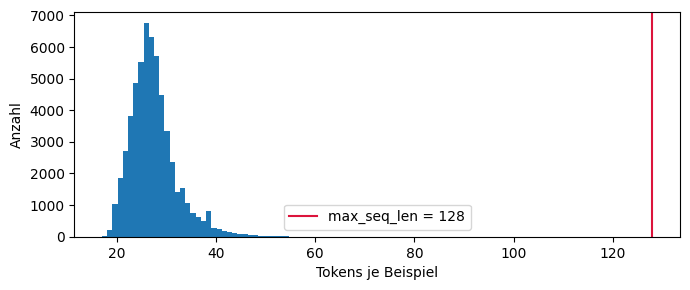

In [32]:
import matplotlib.pyplot as plt

laengen = sorted(len(tokenizer.encode(t).ids) for t in texte["train"])
for q in (0.5, 0.95, 0.99, 1.0):
    print(f"  {q:5.0%}-Quantil: {laengen[min(int(q*len(laengen)), len(laengen)-1)]:3d} Tokens")

plt.figure(figsize=(7, 3))
plt.hist(laengen, bins=40)
plt.axvline(128, color="crimson", label="max_seq_len = 128")
plt.xlabel("Tokens je Beispiel"); plt.ylabel("Anzahl"); plt.legend()
plt.tight_layout(); plt.show()

## 3. Von Text zu Tensoren

Ein Sprachmodell sagt zu jeder Position das **nächste** Token voraus. Aus einer
Sequenz werden deshalb zwei: die Eingabe `x` ohne das letzte Token, das Ziel `y`
ohne das erste. Beide sind gleich lang und um genau eine Position gegeneinander
verschoben.

Weil Beispiele unterschiedlich lang sind, füllen wir kürzere mit `<pad>` (ID 0)
auf. Diese Füllung darf den Verlust nicht beeinflussen — dafür sorgt später
`ignore_index=0`.

In [33]:
def zu_sequenzen(liste, max_len=128):
    ergebnis = []
    for text in liste:
        ids = tokenizer.encode(text).ids[:max_len]
        if len(ids) >= 2:          # kuerzer waere kein Paar (x, y)
            ergebnis.append(ids)
    return ergebnis

train_seq = zu_sequenzen(texte["train"])
eval_seq  = zu_sequenzen(texte["test"])
print(f"{len(train_seq):,} Trainings-, {len(eval_seq):,} Evaluationssequenzen")


def baue_batch(quelle, indizes, pad_id=0):
    """Baut aus Sequenz-Indizes einen gepaddeten Batch (x, y)."""
    paare = [(quelle[i][:-1], quelle[i][1:]) for i in indizes]
    laenge = max(len(a) for a, _ in paare)
    x = torch.full((len(paare), laenge), pad_id, dtype=torch.long)
    y = torch.full((len(paare), laenge), pad_id, dtype=torch.long)
    for i, (a, b) in enumerate(paare):
        x[i, :len(a)] = torch.tensor(a)
        y[i, :len(b)] = torch.tensor(b)
    return x, y

57,000 Trainings-, 3,000 Evaluationssequenzen


### Beobachtung: Der Versatz um eine Position

Vergleichen Sie die beiden Zeilen unten Spalte für Spalte: `y` ist `x`, um eins
nach links geschoben. An Position 3 steht in `x` das Token, das das Modell sieht,
und in `y` das Token, das es vorhersagen soll.

**Eine bewusste Vereinfachung:** Die Attention maskiert das Padding *nicht*, nur
der Verlust ignoriert es. Ein Produktivmodell braucht zusätzlich eine
Padding-Maske. Überlegen Sie, welchen Schaden das hier anrichtet — und warum er
bei kurzen, ähnlich langen Beispielen klein bleibt.

In [34]:
x, y = baue_batch(train_seq, [0, 1, 2, 3])
print("Form:", tuple(x.shape), "\n")
print("x[0]:", x[0][:12].tolist())
print("y[0]:", y[0][:12].tolist())
print("\nals Text:")
print("  x:", repr(tokenizer.decode(x[0][:12].tolist(), skip_special_tokens=False)))
print("  y:", repr(tokenizer.decode(y[0][:12].tolist(), skip_special_tokens=False)))
print(f"\nPadding-Anteil in diesem Batch: {(y == 0).float().mean():.1%}")

Form: (4, 27) 

x[0]: [1, 70, 46, 144, 167, 65, 980, 2, 46, 1, 71, 46]
y[0]: [70, 46, 144, 167, 65, 980, 2, 46, 1, 71, 46, 778]

als Text:
  x: '<|im_start|>user\nwhat about a tankmate<|im_end|>\n<|im_start|>assistant\n'
  y: 'user\nwhat about a tankmate<|im_end|>\n<|im_start|>assistant\nwould'

Padding-Anteil in diesem Batch: 10.2%


## 4. Das Modell

Wir bauen den Transformer in vier Schritten: **Attention**, **FFN**, **Block**,
**Gesamtmodell**. Nach jedem Schritt steht eine Beobachtungszelle, die das gerade
gebaute Teil einzeln ausprobiert. Erst am Ende setzen wir alles zusammen.

In [35]:
from dataclasses import dataclass, asdict

@dataclass
class GuppyConfig:
    vocab_size: int = 4096
    max_seq_len: int = 128
    d_model: int = 384        # Breite des Residualstroms
    n_layers: int = 6         # Anzahl der Bloecke
    n_heads: int = 6          # Attention-Koepfe je Block
    ffn_hidden: int = 1536    # innere Breite des FFN (4 x d_model)
    dropout: float = 0.1
    pad_id: int = 0
    bos_id: int = 1           # <|im_start|>
    eos_id: int = 2           # <|im_end|>

konfig = GuppyConfig(vocab_size=tokenizer.get_vocab_size())
print(konfig)
print(f"\nDimension je Kopf: {konfig.d_model} / {konfig.n_heads} = "
      f"{konfig.d_model // konfig.n_heads}")

GuppyConfig(vocab_size=2386, max_seq_len=128, d_model=384, n_layers=6, n_heads=6, ffn_hidden=1536, dropout=0.1, pad_id=0, bos_id=1, eos_id=2)

Dimension je Kopf: 384 / 6 = 64


### 4.1 Attention

Jedes Token bildet drei Vektoren: **Query** (wonach suche ich?), **Key**
(was biete ich an?) und **Value** (was gebe ich weiter?). Das Skalarprodukt aus
Query und Key ergibt für jedes Tokenpaar eine Ähnlichkeit; nach Skalierung mit
$\sqrt{d_{\text{head}}}$ und Softmax werden daraus Gewichte, mit denen die Values
gemittelt werden.

Entscheidend ist die **kausale Maske**: Ein Token darf nur nach links schauen.
Ohne sie könnte das Modell die Antwort einfach ablesen, statt sie vorherzusagen.

Das Argument `return_attn` gibt zusätzlich die Gewichtsmatrix zurück. Das Modell
braucht es nicht — es existiert nur, damit wir gleich hineinsehen können.

In [36]:
import math
import torch.nn as nn
import torch.nn.functional as F


def kausale_maske(T, device=None):
    """Untere Dreiecksmatrix: Position i sieht nur 0..i."""
    return torch.tril(torch.ones(T, T, device=device)).view(1, 1, T, T)


class Attention(nn.Module):
    def __init__(self, konfig):
        super().__init__()
        self.n_heads = konfig.n_heads
        self.head_dim = konfig.d_model // konfig.n_heads
        self.qkv = nn.Linear(konfig.d_model, 3 * konfig.d_model)
        self.out = nn.Linear(konfig.d_model, konfig.d_model)
        self.dropout = nn.Dropout(konfig.dropout)

    def forward(self, x, maske=None, return_attn=False):
        B, T, C = x.shape

        # eine Matrixmultiplikation fuer Q, K und V zusammen, dann aufteilen
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)      # je (B, Koepfe, T, head_dim)

        roh = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if maske is not None:
            roh = roh.masked_fill(maske == 0, float("-inf"))
        gewichte = F.softmax(roh, dim=-1)          # (B, Koepfe, T, T)

        y = (self.dropout(gewichte) @ v).transpose(1, 2).contiguous().view(B, T, C)
        y = self.out(y)
        return (y, gewichte) if return_attn else y

### Beobachtung: Was die Maske bewirkt

Unten sehen Sie erst die Maske selbst, dann eine Zeile der Attention-Gewichte
einmal ohne und einmal mit Maske. In der maskierten Fassung stehen rechts von der
aktuellen Position Nullen — dorthin darf nicht geschaut werden. Beide Zeilen
summieren sich trotzdem zu 1, weil Softmax nach dem Maskieren normiert.

Zum Ausprobieren: Setzen Sie `position` auf 0 und auf `T-1`. Wie viele Tokens
stehen dem ersten Token zur Verfügung, wie viele dem letzten?

In [37]:
torch.manual_seed(0)
T, position = 6, 2

probe_attn = Attention(konfig).eval()
probe_x = torch.randn(1, T, konfig.d_model)
maske = kausale_maske(T)

print("Kausale Maske:")
print(maske[0, 0].to(torch.int).numpy())

_, ohne = probe_attn(probe_x, None,  return_attn=True)
_, mit  = probe_attn(probe_x, maske, return_attn=True)

print(f"\nEingabe {tuple(probe_x.shape)}  ->  Gewichte {tuple(mit.shape)}")
print("  (Batch, Koepfe, Ziel-Position, Quell-Position)\n")
print(f"Zeile {position} ohne Maske: {[round(w, 3) for w in ohne[0, 0, position].tolist()]}")
print(f"Zeile {position} mit  Maske: {[round(w, 3) for w in mit[0, 0, position].tolist()]}")
print(f"\nZeilensumme mit Maske: {mit[0, 0, position].sum():.4f}")

Kausale Maske:
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]

Eingabe (1, 6, 384)  ->  Gewichte (1, 6, 6, 6)
  (Batch, Koepfe, Ziel-Position, Quell-Position)

Zeile 2 ohne Maske: [0.126, 0.207, 0.162, 0.239, 0.152, 0.115]
Zeile 2 mit  Maske: [0.254, 0.419, 0.327, 0.0, 0.0, 0.0]

Zeilensumme mit Maske: 1.0000


### 4.2 Das Feed-Forward-Netz

Die Attention mischt Information **zwischen** Positionen. Das FFN verarbeitet
jede Position **für sich**: hochprojizieren, Aktivierung, zurückprojizieren. Hier
sitzt der größere Teil der Parameter eines Blocks.

Als Aktivierung nehmen wir **GELU** in der tanh-Näherung — dieselbe Funktion, die
GPT-2 unter dem Namen `gelu_new` verwendet. ReLU täte es didaktisch auch, aber die
Wahl ist hier nicht frei: Wer das Modell später in LM Studio laden will, muss GELU
nehmen, weil llama.cpp die Aktivierung für diese Architektur fest eingebaut hat.

**Zur Diskussion:** `ffn_hidden` ist das Vierfache von `d_model` — der übliche
Faktor. Rechnen Sie unten nach, wie viele Parameter der Faktor 2 sparen würde,
und überlegen Sie, was ein kleineres FFN bei einem so engen Wortschatz verliert.
Auch hier gilt die Einschränkung von oben: Der Weg nach LM Studio verlangt exakt
Faktor 4.

In [38]:
class FFN(nn.Module):
    def __init__(self, konfig):
        super().__init__()
        self.hoch   = nn.Linear(konfig.d_model, konfig.ffn_hidden)
        self.runter = nn.Linear(konfig.ffn_hidden, konfig.d_model)
        self.dropout = nn.Dropout(konfig.dropout)

    def forward(self, x):
        # tanh-Naeherung: exakt das, was GPT-2 als "gelu_new" rechnet
        return self.dropout(self.runter(F.gelu(self.hoch(x), approximate="tanh")))


def zaehle(modul):
    return sum(p.numel() for p in modul.parameters())


print(f"FFN mit Faktor {konfig.ffn_hidden / konfig.d_model:.0f}: "
      f"{zaehle(FFN(konfig)):,} Parameter")
print(f"FFN mit Faktor 2: "
      f"{zaehle(FFN(GuppyConfig(ffn_hidden=2 * konfig.d_model))):,} Parameter")

FFN mit Faktor 4: 1,181,568 Parameter
FFN mit Faktor 2: 590,976 Parameter


### 4.3 Der Block

Attention und FFN werden **additiv** in einen durchlaufenden Vektor eingespeist,
den Residualstrom. Jeder Baustein schreibt einen Beitrag hinein, statt den Strom
zu ersetzen. Deshalb bleibt der Gradient auch über sechs Blöcke hinweg intakt.

Wir normieren **vor** jedem Baustein (Pre-Norm). Das ist der Grund, warum dieses
Modell ohne aufwendiges Aufwärmen der Lernrate stabil bleibt.

In [39]:
class Block(nn.Module):
    def __init__(self, konfig):
        super().__init__()
        self.norm1 = nn.LayerNorm(konfig.d_model)
        self.attn  = Attention(konfig)
        self.norm2 = nn.LayerNorm(konfig.d_model)
        self.ffn   = FFN(konfig)

    def forward(self, x, maske=None):
        x = x + self.attn(self.norm1(x), maske)   # Beitrag, kein Ersatz
        x = x + self.ffn(self.norm2(x))
        return x


torch.manual_seed(0)
probe_block = Block(konfig).eval()
with torch.no_grad():
    nachher = probe_block(probe_x, maske)

aenderung = (nachher - probe_x).norm() / probe_x.norm()
print(f"Norm des Residualstroms vorher : {probe_x.norm():.3f}")
print(f"Norm des Residualstroms nachher: {nachher.norm():.3f}")
print(f"relative Aenderung durch den Block: {aenderung:.1%}")
print(f"\nParameter je Block: {zaehle(probe_block):,}")

Norm des Residualstroms vorher : 48.449
Norm des Residualstroms nachher: 50.411
relative Aenderung durch den Block: 28.7%

Parameter je Block: 1,774,464


### 4.4 Das Gesamtmodell

Token-Embedding plus Positions-Embedding ergeben den Anfangszustand, dann sechs
Blöcke, eine abschließende Normierung und die Projektion zurück auf das Vokabular.

Eine Besonderheit: `lm_head` und `tok_emb` **teilen sich dieselbe Gewichtsmatrix**
(weight tying). Die Zeile `self.lm_head.weight = self.tok_emb.weight` ist keine
Kopie, sondern dieselbe Matrix unter zwei Namen. Die Begründung: Beide bilden
zwischen Token und Vektor ab, nur in entgegengesetzter Richtung.

In [40]:
class GuppyLM(nn.Module):
    def __init__(self, konfig: GuppyConfig):
        super().__init__()
        self.konfig = konfig
        self.tok_emb = nn.Embedding(konfig.vocab_size, konfig.d_model)
        self.pos_emb = nn.Embedding(konfig.max_seq_len, konfig.d_model)
        self.drop = nn.Dropout(konfig.dropout)
        self.blocks = nn.ModuleList([Block(konfig) for _ in range(konfig.n_layers)])
        self.norm = nn.LayerNorm(konfig.d_model)
        self.lm_head = nn.Linear(konfig.d_model, konfig.vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight     # dieselbe Matrix, nicht eine Kopie
        self.apply(self._init_gewichte)

    def _init_gewichte(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, ziele=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))

        maske = kausale_maske(T, idx.device)
        for block in self.blocks:
            x = block(x, maske)

        logits = self.lm_head(self.norm(x))

        verlust = None
        if ziele is not None:
            verlust = F.cross_entropy(
                logits.view(-1, self.konfig.vocab_size),
                ziele.reshape(-1),
                ignore_index=self.konfig.pad_id,   # Padding zaehlt nicht
            )
        return logits, verlust

### Beobachtung: Wo sitzen die Parameter?

Bevor Sie die Zelle ausführen: Schätzen Sie, welcher Anteil auf die Embeddings
und welcher auf die sechs Blöcke entfällt. Die meisten schätzen die Embeddings
zu hoch.

In [41]:
modell = GuppyLM(konfig)
gesamt = zaehle(modell)

print(f"{'Bauteil':<12}{'Parameter':>12}{'Anteil':>9}")
print("-" * 33)
for name, modul in [("tok_emb", modell.tok_emb), ("pos_emb", modell.pos_emb),
                    ("blocks", modell.blocks), ("norm", modell.norm)]:
    print(f"{name:<12}{zaehle(modul):>12,}{zaehle(modul)/gesamt:>9.1%}")
print("-" * 33)
print(f"{'gesamt':<12}{gesamt:>12,}{'':>9}")

print(f"\nOhne weight tying waeren es {gesamt + zaehle(modell.tok_emb):,} Parameter —")
print(f"die gemeinsame Matrix spart {zaehle(modell.tok_emb)/(gesamt+zaehle(modell.tok_emb)):.0%}.")

Bauteil        Parameter   Anteil
---------------------------------
tok_emb          916,224     7.9%
pos_emb           49,152     0.4%
blocks        10,646,784    91.7%
norm                 768     0.0%
---------------------------------
gesamt        11,612,928         

Ohne weight tying waeren es 12,529,152 Parameter —
die gemeinsame Matrix spart 7%.


### 4.5 Sanity-Check: Was ist ein guter Startwert?

Vor dem Training weiß das Modell nichts. Bei 4096 gleich wahrscheinlichen Tokens
ist die beste Strategie das Raten, und der Kreuzentropie-Verlust einer
Gleichverteilung ist exakt $\ln(4096) \approx 8{,}32$.

Diese Zahl ist der wichtigste einzelne Kontrollwert des ganzen Notebooks.
Liegt der Startverlust deutlich darunter, greift das Modell auf Information zu,
die es nicht haben dürfte. Liegt er weit darüber, ist die Initialisierung kaputt.
Prüfen Sie ihn bei jedem Modell, das Sie je selbst schreiben.

In [42]:
modell.eval()
x_probe, y_probe = baue_batch(train_seq, list(range(8)))
with torch.no_grad():
    _, start_verlust = modell(x_probe, y_probe)

print(f"Verlust bei Zufallsgewichten: {start_verlust:.3f}")
print(f"ln(vocab_size)              : {math.log(konfig.vocab_size):.3f}")
print(f"Abweichung                  : {abs(start_verlust - math.log(konfig.vocab_size)):.3f}")

Verlust bei Zufallsgewichten: 7.921
ln(vocab_size)              : 7.777
Abweichung                  : 0.143


## 5. Training

Die Schleife steht offen im Notebook, nicht in einer Funktion. Pro Schritt:
zufälligen Batch ziehen, Verlust berechnen, Gradienten zurückrechnen, Gewichte
anpassen.

Drei Details, die nicht selbstverständlich sind:

- **Lernraten-Zeitplan.** Erst linear hoch (Warmup), dann als Kosinuskurve
  herunter. Der Zeitplan wird unten geplottet, bevor er benutzt wird.
- **Gradient Clipping.** Begrenzt die Länge des Gradientenvektors auf 1,0 und
  verhindert, dass ein einzelner Ausreißerbatch die Gewichte zerlegt.
- **Feste Evaluationsbatches.** Sie werden einmal gezogen und bleiben gleich —
  sonst wäre jeder Eval-Wert mit dem vorherigen nicht vergleichbar.

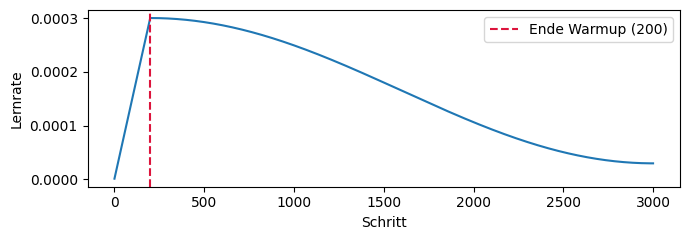

In [43]:
BATCH_SIZE   = 32
LR           = 3e-4
MIN_LR       = 3e-5
WARMUP       = 200
EVAL_ALLE    = 200
WEIGHT_DECAY = 0.1
GRAD_CLIP    = 1.0


def lernrate(schritt):
    if schritt < WARMUP:
        return LR * (schritt + 1) / WARMUP
    fortschritt = (schritt - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return MIN_LR + (LR - MIN_LR) * 0.5 * (1 + math.cos(math.pi * fortschritt))


plt.figure(figsize=(7, 2.5))
plt.plot([lernrate(s) for s in range(MAX_STEPS)])
plt.axvline(WARMUP, color="crimson", ls="--", label=f"Ende Warmup ({WARMUP})")
plt.xlabel("Schritt"); plt.ylabel("Lernrate"); plt.legend()
plt.tight_layout(); plt.show()

In [44]:
import time

torch.manual_seed(42)

# feste Evaluationsbatches — einmal gezogen, danach unveraendert
eval_batches = []
for start in range(0, 10 * BATCH_SIZE, BATCH_SIZE):
    indizes = list(range(start, min(start + BATCH_SIZE, len(eval_seq))))
    if len(indizes) < 2:
        break
    bx, by = baue_batch(eval_seq, indizes)
    eval_batches.append((bx.to(DEVICE), by.to(DEVICE)))


@torch.no_grad()
def bewerte(modell):
    modell.eval()
    summe = sum(modell(bx, by)[1].item() for bx, by in eval_batches)
    modell.train()
    return summe / len(eval_batches)


modell = GuppyLM(konfig).to(DEVICE)
optimierer = torch.optim.AdamW(modell.parameters(), lr=LR,
                               weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))
modell.train()

verlaufsverlust, eval_punkte = [], []
bester_eval = float("inf")
t0 = time.time()

print(f"{'Schritt':>8} | {'Lernrate':>9} | {'Train':>8} | {'Eval':>8} | {'Zeit':>7}")
print("-" * 52)

for schritt in range(MAX_STEPS):
    indizes = torch.randint(0, len(train_seq), (BATCH_SIZE,)).tolist()
    x, y = baue_batch(train_seq, indizes)
    x, y = x.to(DEVICE), y.to(DEVICE)

    lr = lernrate(schritt)
    for gruppe in optimierer.param_groups:
        gruppe["lr"] = lr

    _, verlust = modell(x, y)
    verlust.backward()
    torch.nn.utils.clip_grad_norm_(modell.parameters(), GRAD_CLIP)
    optimierer.step()
    optimierer.zero_grad(set_to_none=True)
    verlaufsverlust.append(verlust.item())

    if schritt % EVAL_ALLE == 0 or schritt == MAX_STEPS - 1:
        ev = bewerte(modell)
        eval_punkte.append((schritt, ev))
        mittel = sum(verlaufsverlust[-EVAL_ALLE:]) / len(verlaufsverlust[-EVAL_ALLE:])
        print(f"{schritt:8d} | {lr:9.6f} | {mittel:8.4f} | {ev:8.4f} | "
              f"{time.time()-t0:6.1f}s")
        if ev < bester_eval:
            bester_eval = ev
            torch.save({"schritt": schritt,
                        "model_state_dict": modell.state_dict(),
                        "konfig": asdict(konfig)},
                       WORK / "checkpoints" / "bestes_modell.pt")

print(f"\nFertig in {time.time()-t0:.0f}s. Bester Eval-Verlust: {bester_eval:.4f}")

 Schritt |  Lernrate |    Train |     Eval |    Zeit
----------------------------------------------------
       0 |  0.000001 |   7.7613 |   7.7233 |    0.4s
     200 |  0.000300 |   4.0905 |   2.5698 |    8.1s
     400 |  0.000297 |   2.1150 |   1.5928 |   15.6s
     600 |  0.000287 |   1.3961 |   1.0316 |   23.2s
     800 |  0.000271 |   0.9547 |   0.7219 |   30.7s
    1000 |  0.000249 |   0.7104 |   0.5774 |   38.0s
    1200 |  0.000224 |   0.5948 |   0.5167 |   45.5s
    1400 |  0.000195 |   0.5325 |   0.4725 |   53.0s
    1600 |  0.000165 |   0.4929 |   0.4489 |   60.6s
    1800 |  0.000135 |   0.4675 |   0.4315 |   68.2s
    2000 |  0.000106 |   0.4459 |   0.4291 |   75.7s
    2200 |  0.000081 |   0.4301 |   0.4151 |   83.1s
    2400 |  0.000059 |   0.4230 |   0.4048 |   90.6s
    2600 |  0.000043 |   0.4118 |   0.4027 |   98.2s
    2800 |  0.000033 |   0.4085 |   0.3996 |  105.7s
    2999 |  0.000030 |   0.4036 |   0.3976 |  112.9s

Fertig in 113s. Bester Eval-Verlust: 0.3976


### Beobachtung: Die Verlustkurve lesen

Der Rohverlust schwankt stark von Batch zu Batch — deshalb der gleitende
Mittelwert. Interessant ist der Abstand zwischen Trainings- und Evaluationskurve:
Solange beide zusammen fallen, lernt das Modell die Sprache. Läuft der
Evaluationsverlust nach oben weg, während der Trainingsverlust weiter fällt,
beginnt Auswendiglernen.

Erinnerung: Der Startwert war $\ln(4096) \approx 8{,}32$.

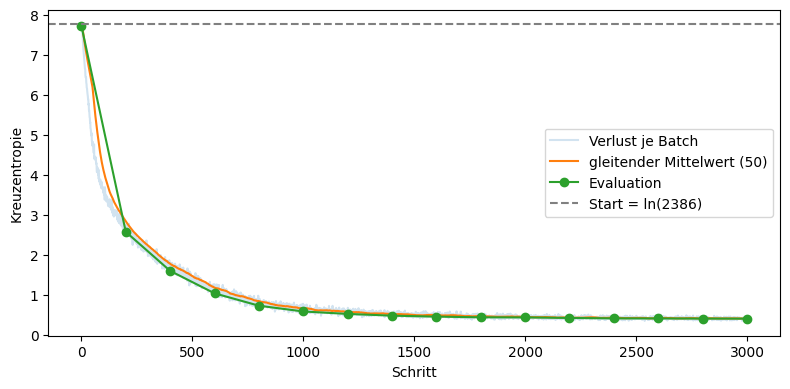

In [45]:
fenster = 50
geglaettet = [sum(verlaufsverlust[max(0, i-fenster):i+1]) /
              len(verlaufsverlust[max(0, i-fenster):i+1])
              for i in range(len(verlaufsverlust))]

plt.figure(figsize=(8, 4))
plt.plot(verlaufsverlust, alpha=0.2, label="Verlust je Batch")
plt.plot(geglaettet, label=f"gleitender Mittelwert ({fenster})")
plt.plot(*zip(*eval_punkte), "o-", label="Evaluation")
plt.axhline(math.log(konfig.vocab_size), color="gray", ls="--",
            label=f"Start = ln({konfig.vocab_size})")
plt.xlabel("Schritt"); plt.ylabel("Kreuzentropie"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Generierung

Trainiert wird auf ganzen Sequenzen parallel, erzeugt wird Token für Token: Das
Modell liefert Logits, daraus wird ein Token gezogen, das Token wird angehängt,
und das Ganze beginnt von vorn. Genau diese Schleife macht Textgenerierung
langsam — jedes Token kostet einen vollständigen Durchlauf.

Zwei Stellschrauben steuern, wie mutig gezogen wird:

- **Temperatur** teilt die Logits. Kleine Werte spitzen die Verteilung zu
  (vorhersagbar, wiederholend), große Werte flachen sie ab (kreativ, wirr).
- **top-k** streicht alle außer den `k` wahrscheinlichsten Tokens. Das verhindert,
  dass ein sehr unwahrscheinliches Token die Antwort entgleisen lässt.

In [46]:
@torch.no_grad()
def erzeuge(modell, ids, max_neu=64, temperatur=0.7, top_k=50):
    """Erzeugt Token fuer Token weiter und gibt die vollstaendige ID-Liste zurueck."""
    modell.eval()
    idx = torch.tensor([ids], dtype=torch.long, device=DEVICE)

    for _ in range(max_neu):
        logits, _ = modell(idx[:, -modell.konfig.max_seq_len:])
        logits = logits[:, -1, :] / temperatur          # nur die letzte Position

        if top_k:
            grenze = torch.topk(logits, min(top_k, logits.size(-1))).values[:, -1:]
            logits = logits.masked_fill(logits < grenze, float("-inf"))

        naechstes = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
        idx = torch.cat([idx, naechstes], dim=1)

        if naechstes.item() == modell.konfig.eos_id:   # gelerntes Stoppsignal
            break

    return idx[0].tolist()


def antworte(frage, temperatur=0.7, max_neu=64):
    prompt = f"<|im_start|>user\n{frage}<|im_end|>\n<|im_start|>assistant\n"
    ids = tokenizer.encode(prompt).ids
    neu = erzeuge(modell, ids, max_neu, temperatur)[len(ids):]
    text = tokenizer.decode(neu)
    for marke in ("<|im_end|>", "<|im_start|>"):
        text = text.split(marke)[0]
    return text.strip()

### Beobachtung: Was die Temperatur macht

Dieselbe Frage, dreimal, mit drei Temperaturen. Führen Sie die Zelle mehrfach aus:
Bei 0,1 ändert sich die Antwort kaum, bei 1,5 fast jedes Mal. Achten Sie auch auf
die Länge — bei hoher Temperatur trifft das Modell das `<|im_end|>` seltener und
redet weiter.

In [47]:
frage = "hallo guppy"
for temperatur in (0.1, 0.7, 1.5):
    print(f"T = {temperatur}:")
    for _ in range(2):
        print(f"    {antworte(frage, temperatur=temperatur)}")

T = 0.1:
    i'm curious. i was just doing laps.
    i'm curious. i found a nice spot near the bottom.
T = 0.7:
    i'm ok. i was just practicing my turns.
    i'm ok. fish don't feel much i think. but i feel pretty good.
T = 1.5:
    i think about everything. especially things that look like the crunchy ones.
    hello. i didn't see you there. my eyes are on the sides.


## 7. Gespräch mit dem Modell

Jede Frage steht für sich — das Modell hat kein Gedächtnis über Nachrichten
hinweg, es sieht immer nur den aktuellen Prompt. Mehrturn-Dialoge wären eine
eigene Übung: Man müsste die vorherigen Runden mit in den Prompt schreiben und
darauf achten, dass die 128 Tokens nicht überlaufen.

In [48]:
fragen = [
    "hallo guppy", "hast du hunger", "es ist heute sehr heiss",
    "wie ist das wasser", "magst du blasen", "was ist das internet",
    "bist du manchmal einsam", "die katze schaut dich an",
    "erzaehl mir einen witz", "wovon traeumst du",
    "was ist der sinn des lebens", "gute nacht guppy",
]

for frage in fragen:
    print(f"{frage:<28} -> {antworte(frage)}")

hallo guppy                  -> i'm smart for a fish. which is not very smart overall.
hast du hunger               -> i don't say why. i was wet and then everything shook.
es ist heute sehr heiss      -> i don't say food. i'll be near the heater tube.
wie ist das wasser           -> the water. i'll swim near the bottom.
magst du blasen              -> food. that sounds like a human thing. i only know fish things.
was ist das internet         -> the whole tank vibrated. i'm ok now but i was not ok a moment ago. is it safe now.
bist du manchmal einsam      -> i don't know what i bloodworms. please.
die katze schaut dich an     -> i don't close food.
erzaehl mir einen witz       -> i tried to bring food and talk about daphnia.
wovon traeumst du            -> i have the log. i'll be near the gravel.
was ist der sinn des lebens  -> i don't close enough. i'll be fine near the gravel recovering.
gute nacht guppy             -> the coral piece is beyond me. i only know fish things.


## 8. Speichern und Laden

Ein Checkpoint enthält die Gewichte **und** die Konfiguration. Ohne die
Konfiguration wären die Gewichte nutzlos: Man wüsste nicht, in welche Form sie
gehören. Der Tokenizer liegt bereits als eigene Datei daneben und gehört
untrennbar dazu — ein Modell mit fremdem Tokenizer erzeugt Kauderwelsch.

In [49]:
ckpt = torch.load(WORK / "checkpoints" / "bestes_modell.pt",
                  map_location=DEVICE, weights_only=False)

geladen = GuppyLM(GuppyConfig(**ckpt["konfig"])).to(DEVICE)
geladen.load_state_dict(ckpt["model_state_dict"])
geladen.eval()

print(f"Geladen aus Schritt {ckpt['schritt']}: {zaehle(geladen):,} Parameter")
print(f"Checkpoint: {WORK / 'checkpoints' / 'bestes_modell.pt'}")
print(f"Tokenizer : {WORK / 'data' / 'tokenizer.json'}")

modell = geladen   # ab jetzt antwortet das beste Modell, nicht das letzte
print(f"\nProbe: {antworte('hallo guppy')}")

Geladen aus Schritt 2999: 11,612,928 Parameter
Checkpoint: /Users/thomasjorg/Documents/05_VSCode/CCode/guppy/checkpoints/bestes_modell.pt
Tokenizer : /Users/thomasjorg/Documents/05_VSCode/CCode/guppy/data/tokenizer.json

Probe: i don't know what i look like exactly. but i think i'm cute.


---

### Weiterarbeiten

- **Architektur.** Setzen Sie `n_layers` auf 2 und trainieren Sie erneut. Wie
  weit kommt der Verlust? Danach `n_heads = 1`. Welche der beiden Kürzungen tut
  mehr weh, und passt das zu Ihrer Erwartung?
- **Tokenizer.** Trainieren Sie ihn mit `vocab_size=512`. Wie ändern sich die
  Sequenzlängen aus Abschnitt 2, und was bedeutet das für den Rechenaufwand?
- **Padding-Maske.** Ergänzen Sie die in Abschnitt 3 beschriebene fehlende
  Maskierung in der Attention. Ändert sich der Evaluationsverlust messbar?
- **Positionen.** Ersetzen Sie die gelernten Positions-Embeddings durch feste
  Sinus-Kodierungen. Was gewinnt man, was verliert man?